In [74]:
import matplotlib.pyplot as plt
import numpy as np

# Individual Caches

In [75]:
compression_ratios = [2, 3, 4, 8]

plot_data = {
    "Keys": {
        "Mistral-7B": {
            "RULER": {
                "SVD": [97.9, 97.6, 97.0, None],
                "KMeans": [97.7, 97.5, 95.1, None],
                "KMeans PH": [97.6, 97.2, 95.3, None],
                "xKV-4": [97.9, 98.0, 98.0, 97.2],
            },
            "LongBench": {
                "SVD": [98.0, 94.8, 90.3, None],
                "KMeans": [98.1, 96.8, 94.3, None],
                "KMeans PH": [98.3, 95.9, 93.7, None],
                "xKV-4": [100.6, 100.3, 100.0, 98.3],
            },
        },
        "Llama3.1-8B": {
            "RULER": {
                "SVD": [99.1, 97.6, 64.5, None],
                "KMeans": [99.4, 97.5, 77.2, None],
                "KMeans PH": [99.7, 97.8, 77.8, None],
                "xKV-4": [100.0, 99.7, 99.6, 97.8],
            },
            "LongBench": {
                "SVD": [91.1, 85.5, 77.4, None],
                "KMeans": [94.3, 90.9, 85.5, None],
                "KMeans PH": [96.2, 90.8, 86.8, None],
                "xKV-4": [96.3, 94.9, 93.4, 91.2],
            },
        },
    },
    "Values": {
        "Mistral-7B": {
            "RULER": {
                "SVD": [97.6, 95.6, 84.5, None],
                "KMeans": [97.6, 96.7, 94.1, None],
                "KMeans PH": [97.7, 97.0, 94.6, None],
                "xKV-4": [97.9, 97.9, 97.8, 96.0],
            },
            "LongBench": {
                "SVD": [98.8, 92.3, 85.9, None],
                "KMeans": [99.0, 97.3, 93.8, None],
                "KMeans PH": [98.5, 96.6, 95.1, None],
                "xKV-4": [99.7, 99.8, 99.7, 95.1],
            },
        },
        "Llama3.1-8B": {
            "RULER": {
                "SVD": [99.3, 93.6, 74.2, None],
                "KMeans": [99.3, 98.6, 92.7, None],
                "KMeans PH": [99.5, 98.7, 94.0, None],
                "xKV-4": [99.9, 99.7, 99.3, 96.0],
            },
            "LongBench": {
                "SVD": [89.4, 82.0, 76.9, None],
                "KMeans": [94.2, 90.2, 85.9, None],
                "KMeans PH": [95.0, 93.8, 89.5, None],
                "xKV-4": [95.0, 95.3, 95.8, 88.3],
            },
        },
    },
}

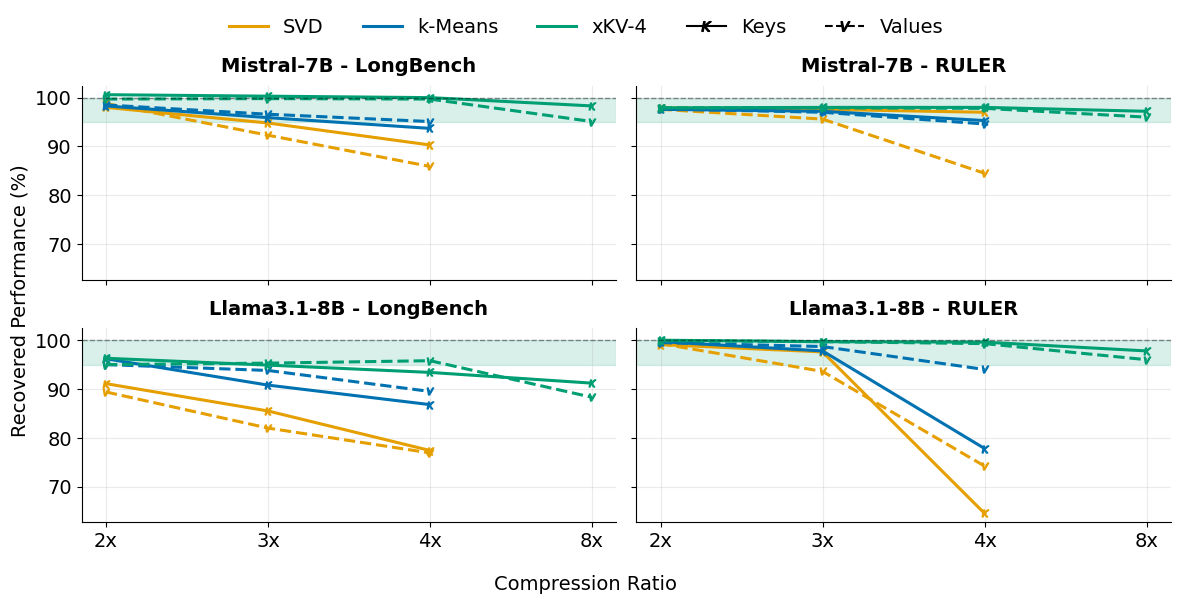

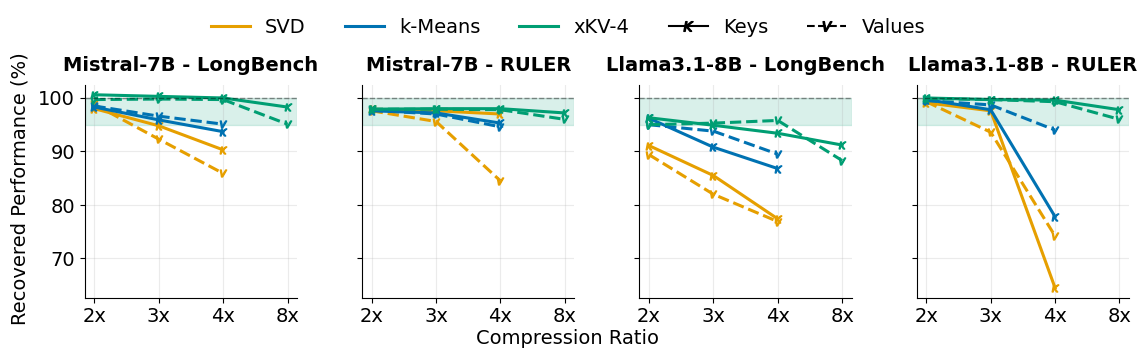

In [76]:
import os

from matplotlib.lines import Line2D

models = ["Mistral-7B", "Llama3.1-8B"]
benchmarks = ["LongBench", "RULER"]
methods = ["SVD", "KMeans PH", "xKV-4"]  # , "KMeans"
colors = {
    "SVD": "#E69F00",
    "KMeans PH": "#0072B2",
    "xKV-4": "#009E73",
}
text_color = "black"
markers = {"Keys": "$K$", "Values": "$V$"}
linestyles = {"Keys": "-", "Values": "--"}
font_size = 14
x_positions = np.arange(len(compression_ratios))


def plot_individual_cache_performance(nrows, ncols, figsize, save_path):
    fig, axes = plt.subplots(
        nrows, ncols, figsize=figsize, sharex=True, sharey=True
    )

    for ax, (model, benchmark) in zip(
        np.asarray(axes).flat,
        ((model, benchmark) for model in models for benchmark in benchmarks),
    ):
        ax.axhspan(95, 100, color="#009E73", alpha=0.15, zorder=0)
        for method in methods:
            for cache_type in ("Keys", "Values"):
                values = plot_data[cache_type][model][benchmark][method]
                ax.plot(
                    x_positions,
                    [np.nan if value is None else value for value in values],
                    color=colors[method],
                    linestyle=linestyles[cache_type],
                    marker=markers[cache_type],
                    markersize=5,
                    linewidth=2.2,
                )

        ax.axhline(
            100, color=text_color, linestyle="--", linewidth=1, alpha=0.4
        )
        ax.set_title(
            f"{model} - {benchmark}",
            color=text_color,
            fontsize=font_size,
            fontweight="bold",
            pad=10,
        )
        ax.set_xticks(
            x_positions,
            labels=[f"{ratio}x" for ratio in compression_ratios],
        )
        if nrows == 1:
            ax.set_box_aspect(1)
        ax.spines[["top", "right"]].set_visible(False)
        ax.spines[["bottom", "left"]].set_color("black")
        ax.tick_params(colors=text_color, labelsize=font_size)
        ax.grid(alpha=0.25)

    fig.supxlabel("Compression Ratio", color=text_color, fontsize=font_size)
    fig.supylabel(
        "Recovered Performance (%)",
        x=0.035 if nrows == 1 else 0.02,
        color=text_color,
        fontsize=font_size,
    )
    method_handles = [
        Line2D(
            [0],
            [0],
            color=colors[method],
            linewidth=2.2,
            label="k-Means" if method == "KMeans PH" else method,
        )
        for method in methods
    ]
    cache_handles = [
        Line2D(
            [0],
            [0],
            color=text_color,
            linestyle=linestyles[cache_type],
            marker=markers[cache_type],
            markersize=7,
            label=cache_type,
        )
        for cache_type in ("Keys", "Values")
    ]
    fig.legend(
        handles=method_handles + cache_handles,
        loc="upper center",
        ncol=len(method_handles) + len(cache_handles),
        bbox_to_anchor=(0.5, 1.08 if nrows == 1 else 1.0),
        fontsize=font_size,
        frameon=False,
    )
    fig.tight_layout(rect=(0, 0, 1, 0.88 if nrows == 1 else 0.93))
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    fig.savefig(save_path, bbox_inches="tight", dpi=300)
    plt.show()


plot_individual_cache_performance(
    2, 2, (12, 6), "plots/svd_individual_perf_comparison.svg"
)
plot_individual_cache_performance(
    1, 4, (12, 3.25), "plots/svd_individual_perf_comparison_horizontal.svg"
)

# Combined Caches

In [77]:
compression_ratios = [2, 3, 4, 8]

kv_plot_data = {
    "Mistral-7B": {
        "LongBench": {
            "SVD": [95.8, 84.9, 72.0, None],
            "KMeans": [96.5, 93.1, 86.7, None],
            "KMeans PH": [95.3, 92.6, 87.8, None],
            "xKV-2": [99.7, 99.2, 96.8, 83.0],
            "xKV-4": [99.9, 99.3, 99.0, 91.6],
        },
        "RULER": {
            "SVD": [96.8, 91.1, 62.6, None],
            "KMeans": [97.3, 93.8, 72.1, None],
            "KMeans PH": [97.1, 94.2, 71.7, None],
            "xKV-2": [97.8, 97.7, 97.3, 77.6],
            "xKV-4": [97.8, 97.8, 97.5, 81.0],
        },
    },
    "Llama3.1-8B": {
        "LongBench": {
            "SVD": [86.8, 74.5, 63.6, None],
            "KMeans": [91.9, 84.6, 77.1, None],
            "KMeans PH": [94.4, 87.2, 80.7, None],
            "xKV-2": [94.9, 96.7, 92.8, 78.8],
            "xKV-4": [93.8, 94.2, 94.6, 84.1],
        },
        "RULER": {
            "SVD": [94.7, 66.4, 29.9, None],
            "KMeans": [98.5, 83.3, 43.5, None],
            "KMeans PH": [98.7, 82.2, 44.2, None],
            "xKV-2": [99.3, 97.8, 94.9, 76.8],
            "xKV-4": [99.5, 99.1, 97.7, 79.6],
        },
    },
}

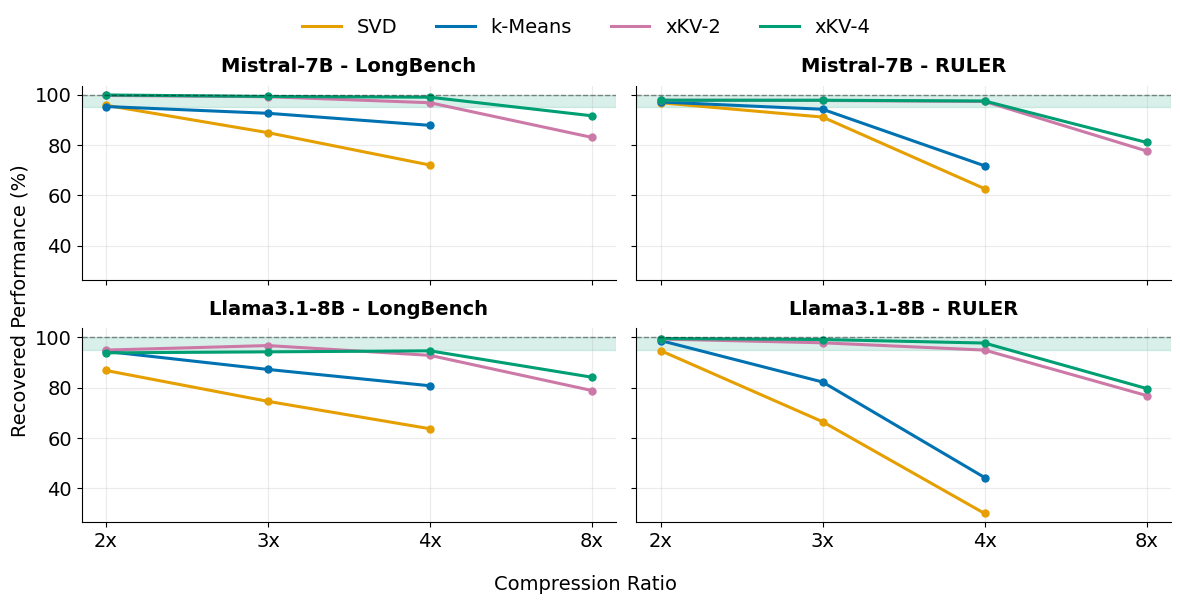

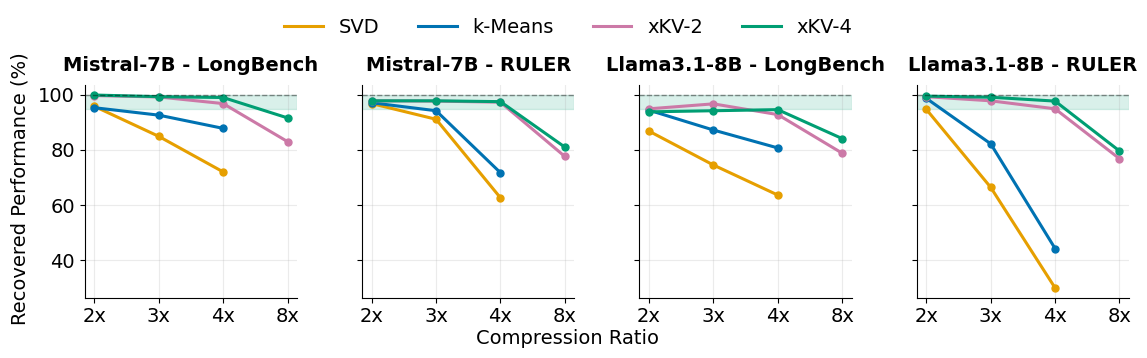

In [78]:
import os

from matplotlib.lines import Line2D

models = ["Mistral-7B", "Llama3.1-8B"]
benchmarks = ["LongBench", "RULER"]
kv_methods = ["SVD", "KMeans PH", "xKV-2", "xKV-4"]  # , "KMeans"
kv_colors = {
    "SVD": "#E69F00",
    "KMeans PH": "#0072B2",
    "xKV-2": "#CC79A7",
    "xKV-4": "#009E73",
}
text_color = "black"
font_size = 14
x_positions = np.arange(len(compression_ratios))


def plot_combined_cache_performance(nrows, ncols, figsize, save_path):
    fig, axes = plt.subplots(
        nrows, ncols, figsize=figsize, sharex=True, sharey=True
    )

    for ax, (model, benchmark) in zip(
        np.asarray(axes).flat,
        ((model, benchmark) for model in models for benchmark in benchmarks),
    ):
        ax.axhspan(95, 100, color="#009E73", alpha=0.15, zorder=0)
        for method in kv_methods:
            values = kv_plot_data[model][benchmark][method]
            ax.plot(
                x_positions,
                [np.nan if value is None else value for value in values],
                color=kv_colors[method],
                marker="o",
                markersize=5,
                linewidth=2.2,
            )

        ax.axhline(
            100, color=text_color, linestyle="--", linewidth=1, alpha=0.4
        )
        ax.set_title(
            f"{model} - {benchmark}",
            color=text_color,
            fontsize=font_size,
            fontweight="bold",
            pad=10,
        )
        ax.set_xticks(
            x_positions,
            labels=[f"{ratio}x" for ratio in compression_ratios],
        )
        if nrows == 1:
            ax.set_box_aspect(1)
        ax.spines[["top", "right"]].set_visible(False)
        ax.spines[["bottom", "left"]].set_color("black")
        ax.tick_params(colors=text_color, labelsize=font_size)
        ax.grid(alpha=0.25)

    fig.supxlabel("Compression Ratio", color=text_color, fontsize=font_size)
    fig.supylabel(
        "Recovered Performance (%)",
        x=0.035 if nrows == 1 else 0.02,
        color=text_color,
        fontsize=font_size,
    )
    fig.legend(
        handles=[
            Line2D(
                [0],
                [0],
                color=kv_colors[method],
                linewidth=2.2,
                label="k-Means" if method == "KMeans PH" else method,
            )
            for method in kv_methods
        ],
        loc="upper center",
        ncol=len(kv_methods),
        bbox_to_anchor=(0.5, 1.08 if nrows == 1 else 1.0),
        fontsize=font_size,
        frameon=False,
    )
    fig.tight_layout(rect=(0, 0, 1, 0.88 if nrows == 1 else 0.93))
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    fig.savefig(save_path, bbox_inches="tight", dpi=300)
    plt.show()


plot_combined_cache_performance(
    2, 2, (12, 6), "plots/svd_combined_perf_comparison.svg"
)
plot_combined_cache_performance(
    1, 4, (12, 3.25), "plots/svd_combined_perf_comparison_horizontal.svg"
)